In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.7 MB/s eta 0:00:00


In [ ]:
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from gensim.models import Word2Vec
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.optimizers import Adam,SGD
from keras.regularizers import l2
from tensorflow.keras.layers import Bidirectional,LSTM,Dense,Embedding,Dropout,BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os

# --- Kaggle API setup and dataset download for Colab environment ---

# Install Kaggle API client
!pip install kaggle --quiet

# Create .kaggle directory and move kaggle.json for authentication
# The kaggle.json file is expected to be present at /content/kaggle.json as per kernel state.
!mkdir -p ~/.kaggle
!mv /content/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# Download the 'SMS Spam Collection Dataset' to the current directory
# The dataset ID is 'uciml/sms-spam-collection-dataset'
!kaggle datasets download -d uciml/sms-spam-collection-dataset -p .

# Unzip the downloaded file. The zip file usually contains 'spam.csv'.
# The downloaded file is typically named after the dataset ID, so 'sms-spam-collection-dataset.zip'.
!unzip -o sms-spam-collection-dataset.zip

# Verify the contents after unzipping
print("Files in current directory after download and extraction:")
for dirname, _, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# --- End of Kaggle API setup ---

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

mv: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown
100% 211k/211k [00:00<00:00, 258kB/s]

Archive:  sms-spam-collection-dataset.zip
  inflating: spam.csv                
Files in current directory after download and extraction:
./spam.csv
./sms-spam-collection-dataset.zip
./.config/active_config
./.config/gce
./.config/.last_update_check.json
./.config/config_sentinel
./.config/.last_survey_prompt.yaml
./.config/default_configs.db
./.config/.last_opt_in_prompt.yaml
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./.config/configurations/config_default
./.config/logs/2026.02.06/14.30.32.592228.log
./.config/logs/2026.02.06/14.31.45.734270.log
./.config/logs/2026.02.06/14.31.35.535753.log
./.config/logs/2026.02.06/14.31.44.938153.log
./.config/logs/2026.02.06/14.31.19.332851.l

In [ ]:
df=pd.read_csv('spam.csv', encoding='latin-1')

In [ ]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4090,ham,Hey doc pls I want to get nice t shirt for my ...,NaN,NaN,NaN
3904,spam,Do you want a new video handset? 750 anytime a...,NaN,NaN,NaN
1047,spam,1000's flirting NOW! Txt GIRL or BLOKE & ur NA...,NaN,NaN,NaN
313,ham,"Hi the way I was with u 2day, is the normal wa...",NaN,NaN,NaN
4343,ham,Hi:)did you asked to waheeda fathima about leave?,NaN,NaN,NaN


In [ ]:
df=df[['v1','v2']]

In [ ]:
df.sample(5)

,v1,v2
954,spam,Filthy stories and GIRLS waiting for your
2098,ham,"No dice, art class 6 thru 9 :( thanks though. ..."
4301,ham,Aiyar hard 2 type. U later free then tell me t...
2657,ham,Dai &lt;#&gt; naal eruku.
854,ham,Stop the story. I've told him i've returned it...


In [ ]:
df.columns=['Label','message']

# text preprocessing

In [ ]:
sms=[]
for i in range(len(df)):
  text=re.sub('[^a-zA-Z]',' ',df['message'][i])
  text=text.lower()
  text=text.split()
  text=[WordNetLemmatizer().lemmatize(word) for word in text if word not in stopwords.words('english')]
  text=' '.join(text)
  sms.append([text])


NameError: name 're' is not defined

In [ ]:
sms

[['go jurong point crazy available bugis n great world la e buffet cine got amore wat'],
 ['ok lar joking wif u oni'],
 ['free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply'],
 ['u dun say early hor u c already say'],
 ['nah think go usf life around though'],
 ['freemsg hey darling week word back like fun still tb ok xxx std chgs send rcv'],
 ['even brother like speak treat like aid patent'],
 ['per request melle melle oru minnaminunginte nurungu vettam set callertune caller press copy friend callertune'],
 ['winner valued network customer selected receivea prize reward claim call claim code kl valid hour'],
 ['mobile month u r entitled update latest colour mobile camera free call mobile update co free'],
 ['gonna home soon want talk stuff anymore tonight k cried enough today'],
 ['six chance win cash pound txt csh send cost p day day tsandcs apply reply hl info'],
 ['urgent week free membership prize jackpot txt word claim c www dbuk 

In [ ]:
model=Word2Vec(sms,min_count=1)

- here we have created vectors for each sentence now will create training data out of it

In [ ]:
X = []
for msg in sms:
    # msg is a list containing one string, e.g., [['go jurong point crazy available bugis n great world la e buffet cine got amore wat']]
    # We need to process the string inside the list.
    word_vectors = []
    # Split the message string into individual words
    words = msg[0].split()
    for word in words:
        if word in model.wv:
            word_vectors.append(model.wv[word])

    if len(word_vectors) > 0:
        # Average the word vectors to get a sentence vector
        X.append(np.mean(word_vectors, axis=0))
    else:
        # If no words in the message are in the vocabulary, append a zero vector
        X.append(np.zeros(model.vector_size))

X = np.array(X)

# Display the shape of the generated feature matrix
print(f"Shape of feature matrix X: {X.shape}")

Shape of feature matrix X: (5572, 100)


In [ ]:
X[0]

array([ 8.56364844e-04,  5.64169604e-03, -3.52907320e-03, -5.32576628e-03,
       -4.49516810e-05, -4.57017962e-03,  3.31221870e-03, -9.53022856e-04,
       -1.33700925e-03,  3.52053205e-03,  6.93764584e-03, -2.46715732e-04,
        1.12097245e-04,  6.92344969e-03,  6.99495990e-03, -2.41758954e-03,
       -4.17845789e-04, -6.38624467e-03,  7.21228716e-04, -2.12454796e-03,
        1.77943299e-03, -7.84756383e-04, -4.30410216e-03,  7.72615056e-03,
       -5.44258486e-03,  6.22861506e-03, -3.22412746e-03,  9.92670073e-04,
       -1.58717507e-03,  5.69509901e-03,  4.21197386e-03, -7.99559988e-04,
        1.71283470e-03,  7.07277679e-04,  2.41334643e-03,  3.43003450e-03,
        3.82632599e-04, -7.42108189e-03, -2.25142413e-03,  2.86398525e-03,
        9.94308735e-04, -1.66280381e-03, -2.67933961e-03, -6.82378840e-03,
        4.81867185e-03, -2.36066990e-03, -3.54832597e-03,  3.88830202e-04,
       -6.10888936e-03, -5.13876788e-03,  5.98019548e-03, -1.32060586e-03,
        1.04958005e-03, -

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['Label'])


<Axes: xlabel='0'>

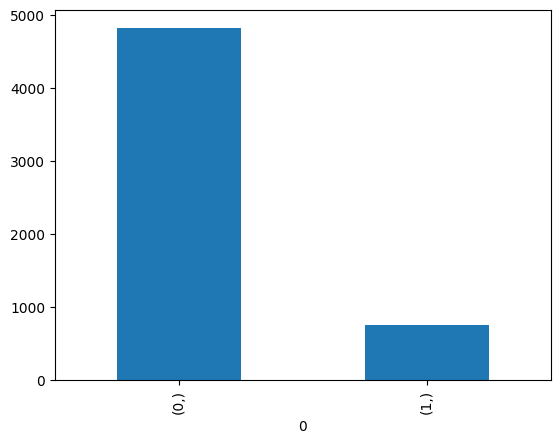

In [ ]:
pd.DataFrame(y).value_counts().plot(kind='bar')

# Here there is class imbalance

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=42)

In [ ]:
smote=SMOTE()
x_train,y_train=smote.fit_resample(x_train,y_train)

In [ ]:
x_train.shape

(8668, 100)

# LSTM layers expect input with three dimensions: (number_of_samples, number_of_timesteps, number_of_features).

In [ ]:
# Reshape x_train and x_test for LSTM input
x_train_reshaped = x_train.reshape(x_train.shape[0], 1, x_train.shape[1])
x_test_reshaped = x_test.reshape(x_test.shape[0], 1, x_test.shape[1])

print(f"Reshaped x_train shape: {x_train_reshaped.shape}")
print(f"Reshaped x_test shape: {x_test_reshaped.shape}")

Reshaped x_train shape: (8668, 1, 100)
Reshaped x_test shape: (558, 1, 100)


- he timesteps dimension is set to 1 because of how we created our X feature matrix.

We processed each message by taking all its words, finding their Word2Vec embeddings, and then averaging those word embeddings to get a single vector. This single vector represents the entire message.

Since each message is already condensed into one representative vector, when we feed it to the LSTM, it's considered a sequence of just one item – that one averaged message vector. If we had kept each word's vector separate and fed them sequentially (e.g., [[word1_vec], [word2_vec], [word3_vec]] for a three-word message), then the timesteps would be the number of words in the message. But in our current setup, each X entry is already the combined representation of a message.



In [ ]:
# Define the input dimension (vector dimension for each word)
input_dim = x_train_reshaped.shape[2]

# return_sequences=False means this is the final layer before output if we want to add another layer then make it true
model = Sequential()
model.add(Bidirectional(LSTM(128, return_sequences=True,kernel_regularizer=l2(0.001)), input_shape=(1, input_dim)))
model.add(Dropout(0.3))
model.add(BatchNormalization())
model.add(Bidirectional(LSTM(64,kernel_regularizer=l2(0.001))))
model.add(Dropout(0.3))
model.add(BatchNormalization())
model.add(Dense(1, activation='sigmoid')) # Binary classification, so 1 output unit with sigmoid activation

# Compile the model
model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_37                │ (None, 1, 256)         │       234,496 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 1, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_38                │ (None, 128)            │       164,352 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 400,513 (1.53 MB)

 Trainable params: 399,745 (1.52 MB)

 Non-trainable params: 768 (3.00 KB)

- input_shape=(1, input_dim) tells the Bidirectional LSTM to expect input where each sample is a sequence of 1 timestep, and that single timestep is a vector of input_dim features. here 100 is the vector dimension

In [ ]:
earlystop=EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reducelr=ReduceLROnPlateau(
    factor=0.2,
    min_lr=0.0001,
    monitor='val_loss',
    patience=10,
)

In [ ]:
history = model.fit(x_train_reshaped, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1,callbacks=[earlystop,reducelr])

Epoch 1/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7401 - loss: 0.9448 - val_accuracy: 0.0000e+00 - val_loss: 0.9358 - learning_rate: 0.0010
Epoch 2/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7776 - loss: 0.6014 - val_accuracy: 0.4983 - val_loss: 0.7808 - learning_rate: 0.0010
Epoch 3/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7720 - loss: 0.5644 - val_accuracy: 0.5755 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 4/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7833 - loss: 0.5282 - val_accuracy: 0.6701 - val_loss: 0.5570 - learning_rate: 0.0010
Epoch 5/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7746 - loss: 0.5134 - val_accuracy: 0.6967 - val_loss: 0.5446 - learning_rate: 0.0010
Epoch 6/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7786 - loss: 0.5027 - val_accuracy: 0.5456 - val_loss: 0.7623 - learning_rate: 0.0010
Epoch 7/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7757 - loss

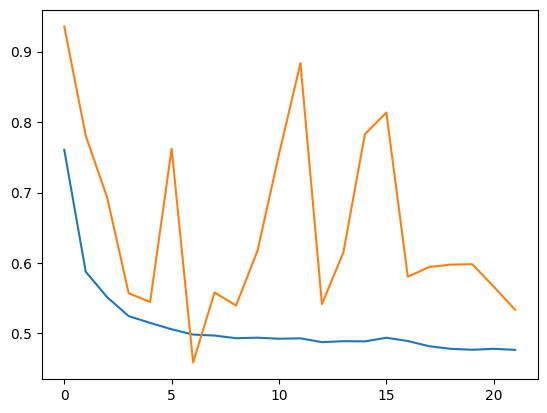

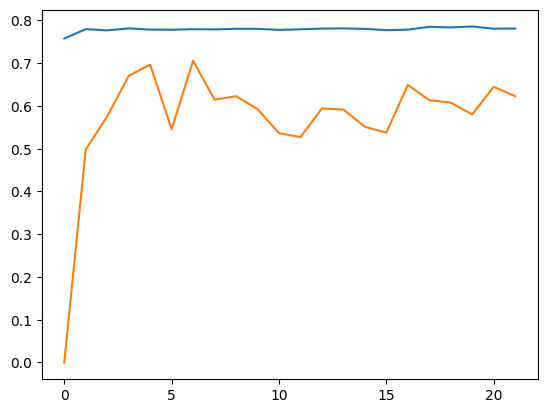

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])


In [ ]:
y_train_pred_probs = model.predict(x_train_reshaped)
y_train_pred = (y_train_pred_probs > 0.5).astype(int)

y_test_pred_probs = model.predict(x_test_reshaped)
y_test_pred = (y_test_pred_probs > 0.5).astype(int)


271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [ ]:
from sklearn.metrics import classification_report

target_names = ['ham', 'spam']

# Generate the classification report for the training set
report_train = classification_report(y_train, y_train_pred, target_names=target_names)

print("--- Classification Report for Training Data ---")
print(report_train)

--- Classification Report for Training Data ---
              precision    recall  f1-score   support

         ham       0.75      0.83      0.79      4334
        spam       0.81      0.72      0.76      4334

    accuracy                           0.78      8668
   macro avg       0.78      0.78      0.78      8668
weighted avg       0.78      0.78      0.78      8668



In [ ]:
from sklearn.metrics import classification_report

target_names = ['ham', 'spam']

# Generate the classification report for the test set
report_test = classification_report(y_test, y_test_pred, target_names=target_names)

print("--- Classification Report for Test Data ---")
print(report_test)

--- Classification Report for Test Data ---
              precision    recall  f1-score   support

         ham       0.97      0.84      0.90       491
        spam       0.41      0.82      0.55        67

    accuracy                           0.84       558
   macro avg       0.69      0.83      0.72       558
weighted avg       0.90      0.84      0.86       558



### Testing 5 Sample Messages from the Test Data

In [ ]:
import random

# Ensure test_idx is available (it should be from previous steps)
# If it's not, you might need to re-run the train_test_split cell that generates it.

# Select 5 random indices from the test set
num_samples_to_test = 5
sample_test_indices = random.sample(range(len(test_idx)), num_samples_to_test)

print("--- Sample Test Messages and Predictions ---")
for i in sample_test_indices:
    # Get the original index in the dataframe from test_idx
    original_df_index = test_idx[i]

    # Get the original message from the full dataframe 'df'
    original_message = df['message'].iloc[original_df_index]

    # Get the true label for the test set sample
    true_label = le.inverse_transform(y_test[i:i+1])[0]

    # Get the predicted label for the test set sample
    # y_test_pred is already 0 or 1. Ensure it's a 1D array for inverse_transform.
    predicted_label = le.inverse_transform(y_test_pred[i])[0]

    print(f"\nMessage: {original_message}")
    print(f"True Label: {true_label}")
    print(f"Predicted Label: {predicted_label}")
    print("------------------------------------")

--- Sample Test Messages and Predictions ---

Message: She.s fine. I have had difficulties with her phone. It works with mine. Can you pls send her another friend request.
True Label: ham
Predicted Label: spam
------------------------------------

Message: God picked up a flower and dippeditinaDEW, lovingly touched itwhichturnedinto u, and the he gifted tomeandsaid,THIS FRIEND IS 4U
True Label: ham
Predicted Label: spam
------------------------------------

Message: What you did in  leave.
True Label: ham
Predicted Label: ham
------------------------------------

Message: Long after I quit. I get on only like 5 minutes a day as it is.
True Label: ham
Predicted Label: ham
------------------------------------

Message: I'm in a meeting, call me later at
True Label: ham
Predicted Label: spam
------------------------------------


# Implementing RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the RandomForestClassifier
# You can tune hyperparameters like n_estimators, max_depth, etc.
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier
print("Training RandomForestClassifier...")
rf_classifier.fit(x_train, y_train)
print("RandomForestClassifier training complete.")

Training RandomForestClassifier...
RandomForestClassifier training complete.


In [ ]:
# Make predictions on the test set
y_pred_rf_train = rf_classifier.predict(x_train)

y_pred_rf_test = rf_classifier.predict(x_test)

# Generate classification report

print("--- RandomForestClassifier Classification Report (Train Data) ---")
print(classification_report(y_train, y_pred_rf_train, target_names=['ham', 'spam']))


print("--- RandomForestClassifier Classification Report (Test Data) ---")
print(classification_report(y_test, y_pred_rf_test, target_names=['ham', 'spam']))


--- RandomForestClassifier Classification Report (Train Data) ---
              precision    recall  f1-score   support

         ham       0.76      0.95      0.84      4334
        spam       0.94      0.70      0.80      4334

    accuracy                           0.82      8668
   macro avg       0.85      0.82      0.82      8668
weighted avg       0.85      0.82      0.82      8668

--- RandomForestClassifier Classification Report (Test Data) ---
              precision    recall  f1-score   support

         ham       0.96      0.96      0.96       491
        spam       0.70      0.69      0.69        67

    accuracy                           0.93       558
   macro avg       0.83      0.82      0.83       558
weighted avg       0.93      0.93      0.93       558



# The Transformers Approach


In [2]:
df=pd.read_csv('spam.csv', encoding='latin-1')

In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2576,ham,In sch but neva mind u eat 1st lor..,NaN,NaN,NaN
577,ham,ÌÏ wait 4 me in sch i finish ard 5..,NaN,NaN,NaN
3237,ham,Good. No swimsuit allowed :),NaN,NaN,NaN
799,ham,"\Gimme a few\"" was &lt;#&gt; minutes ago""",NaN,NaN,NaN
4831,ham,Rats. Hey did u ever vote for the next themes?,NaN,NaN,NaN


In [4]:
df=df[['v1','v2']]

In [5]:
df.sample(5)

,v1,v2
4231,ham,I'm at home. Please call
1903,spam,Free entry in 2 a weekly comp for a chance to ...
4154,spam,Want a new Video Phone? 750 anytime any networ...
3735,ham,Hows the street where the end of library walk is?
3189,ham,Hi neva worry bout da truth coz the truth will...


In [6]:
x=df['v2']

In [7]:
y=df['v1']

In [8]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

In [9]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [10]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [11]:
!pip install transformers

# Steps for applying transformer
1. call the pretrained model search on the hugging face models which is better for sms spam (DistilBert)
2. Call the tokenizer, since different models have their own tokenizer
3. Convert this encodings into Dataset objects
4. Train BERT and evaluate

 # Load the Dataset

In [12]:
import torch
from transformers import BertTokenizer,BertForSequenceClassification
#These imports are from the Hugging Face Transformers library.
#BertTokenizer is used to convert text into a format (tokens and IDs) that BERT models can understand.
#BertForSequenceClassification is a BERT model specifically fine-tuned or pre-trained for classification tasks.
from transformers import Trainer,TrainingArguments
#These are also from the Hugging Face Transformers library. Trainer is a high-level API to simplify the training and evaluation of models,
#while TrainingArguments defines the various parameters for the training process, such as learning rate, batch size, and number of epochs.
from datasets import Dataset
# It's designed to work seamlessly with models from the Hugging Face Transformers library, making it easier to prepare data for training models like BERT.

# Convert into HuggingFace Dataset

In [13]:
train_dataset=Dataset.from_dict({
    "text":x_train.tolist(),
    "label":y_train.tolist()
})
val_dataset=Dataset.from_dict({
    "text":x_test.tolist(),
    "label":y_test.tolist()
})


# Load the Tokenizer

In [15]:
tokenizer=BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# TOkenization function

In [16]:
def tokenize(example):
  return tokenizer(example["text"],padding="max_length",truncation=True)

In [17]:
train_dataset=train_dataset.map(tokenize,batched=True)
val_dataset=val_dataset.map(tokenize,batched=True)


Map:   0%|          | 0/4457 [00:00<?, ? examples/s]

Map:   0%|          | 0/1115 [00:00<?, ? examples/s]

# Load the Pre-Trained BERT

In [18]:
model=BertForSequenceClassification.from_pretrained("bert-base-uncased",num_labels=2)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Training Arguments

In [34]:
training_args=TrainingArguments(
    output_dir='./results',
    learning_rate=0.01,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    logging_dir='./logs',
    logging_steps=50
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


# Trainer

In [35]:
trainer=Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,

)

# Train

In [36]:
trainer.train()

Step,Training Loss


KeyboardInterrupt: 

# Evaluate

In [ ]:
trainer.evaluate()

# Prediction Function

In [ ]:
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    outputs = model(**inputs)
    logits = outputs.logits

    predicted_class = torch.argmax(logits, dim=1).item()

    return "Spam" if predicted_class == 1 else "Ham"

In [ ]:
print(predict("Congratulations! You won a free iPhone"))

# Train Classification report

In [33]:
from sklearn.metrics import classification_report

# Predict on TRAIN data
train_predictions = trainer.predict(train_dataset)

y_train_pred = train_predictions.predictions.argmax(axis=1)
y_train_true = train_predictions.label_ids

print("🔹 Train Classification Report:\n")
print(classification_report(y_train_true, y_train_pred, target_names=["Ham", "Spam"]))

Step,Training Loss


KeyboardInterrupt: 

# Test Classificaiotion report

In [ ]:
# Predict on TEST / VALIDATION data
val_predictions = trainer.predict(val_dataset)

y_val_pred = val_predictions.predictions.argmax(axis=1)
y_val_true = val_predictions.label_ids

print("🔹 Test Classification Report:\n")
print(classification_report(y_val_true, y_val_pred, target_names=["Ham", "Spam"]))

# Get training Logs

In [31]:
import pandas as pd

logs = trainer.state.log_history
df_logs = pd.DataFrame(logs)

/tmp/ipykernel_1929/324166587.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


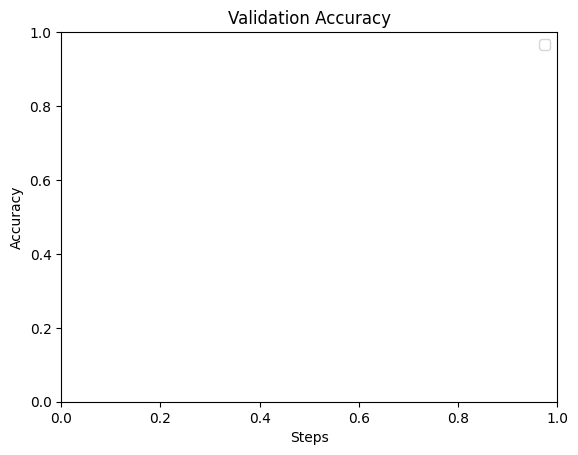

/tmp/ipykernel_1929/324166587.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


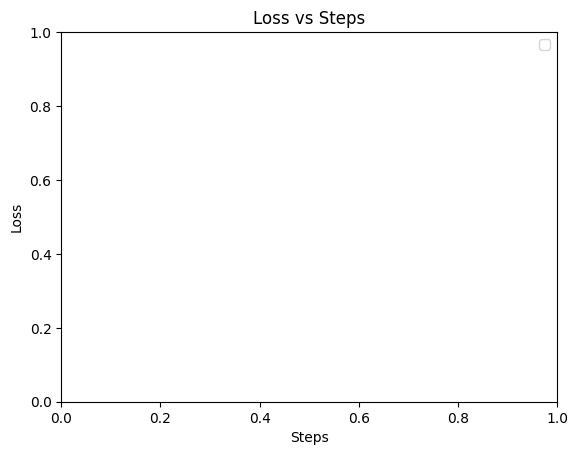

In [32]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure()
if "eval_accuracy" in df_logs:
    plt.plot(df_logs["eval_accuracy"].dropna(), label="Validation Accuracy")
plt.title("Validation Accuracy")
plt.xlabel("Steps")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss Plot
plt.figure()
if "loss" in df_logs:
    plt.plot(df_logs["loss"].dropna(), label="Training Loss")
if "eval_loss" in df_logs:
    plt.plot(df_logs["eval_loss"].dropna(), label="Validation Loss")

plt.title("Loss vs Steps")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.show()